In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('traffic.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
df.head()

Shape: (48120, 4)

Columns: ['DateTime', 'Junction', 'Vehicles', 'ID']

Dtypes:
 DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nUnique Junctions:", df['Junction'].unique())
print("\nDateTime range:", df['DateTime'].min(), "to", df['DateTime'].max())
print("\nSummary statistics:")
df.describe()

Missing values:
 DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Duplicates: 0

Unique Junctions: [1 2 3 4]

DateTime range: 2015-11-01 00:00:00 to 2017-06-30 23:00:00

Summary statistics:


,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [3]:
# --- Cleaning & Feature Engineering ---
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.drop(columns=['ID']).sort_values('DateTime').reset_index(drop=True)

df['Hour']      = df['DateTime'].dt.hour
df['Day']       = df['DateTime'].dt.day
df['Month']     = df['DateTime'].dt.month
df['Year']      = df['DateTime'].dt.year
df['Weekday']   = df['DateTime'].dt.weekday
df['DayName']   = df['DateTime'].dt.day_name()
df['IsWeekend'] = (df['Weekday'] >= 5).astype(int)

print("Cleaned dataset shape:", df.shape)
print("Dtypes:\n", df.dtypes)
df.head()

Cleaned dataset shape: (48120, 10)
Dtypes:
 DateTime     datetime64[ns]
Junction              int64
Vehicles              int64
Hour                  int32
Day                   int32
Month                 int32
Year                  int32
Weekday               int32
DayName              object
IsWeekend             int64
dtype: object


,DateTime,Junction,Vehicles,Hour,Day,Month,Year,Weekday,DayName,IsWeekend
0,2015-11-01 00:00:00,1,15,0,1,11,2015,6,Sunday,1
1,2015-11-01 00:00:00,2,6,0,1,11,2015,6,Sunday,1
2,2015-11-01 00:00:00,3,9,0,1,11,2015,6,Sunday,1
3,2015-11-01 01:00:00,3,7,1,1,11,2015,6,Sunday,1
4,2015-11-01 01:00:00,1,13,1,1,11,2015,6,Sunday,1


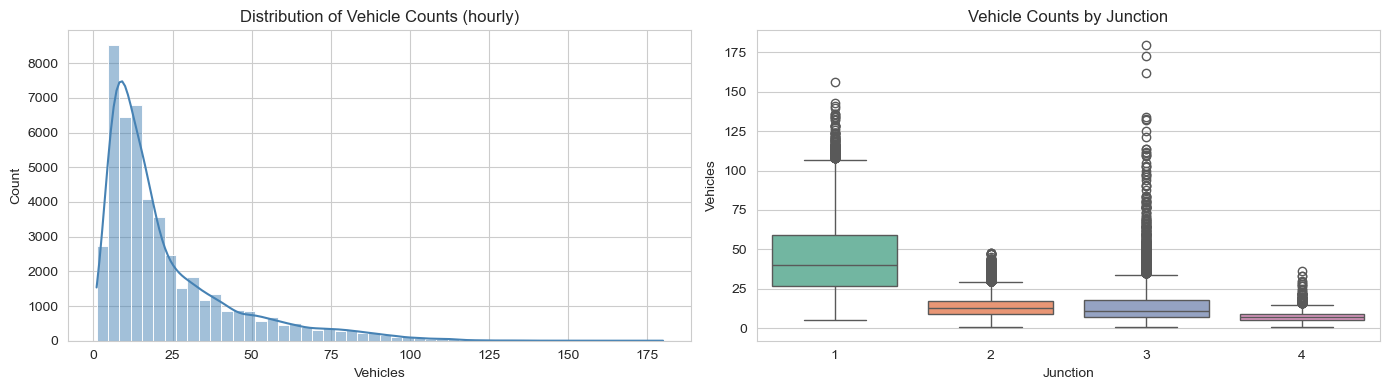

Mean vehicles per junction:
               mean  median        std  max
Junction                                   
1         45.052906    40.0  23.008345  156
2         14.253221    13.0   7.401307   48
3         13.694010    11.0  10.436005  180
4          7.251611     7.0   3.521455   36


In [4]:
# --- EDA: Distributions & Junction Overview ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Vehicles'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Vehicle Counts (hourly)')
axes[0].set_xlabel('Vehicles')

sns.boxplot(x='Junction', y='Vehicles', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Vehicle Counts by Junction')

plt.tight_layout()
plt.show()

print("Mean vehicles per junction:")
print(df.groupby('Junction')['Vehicles'].agg(['mean', 'median', 'std', 'max']))

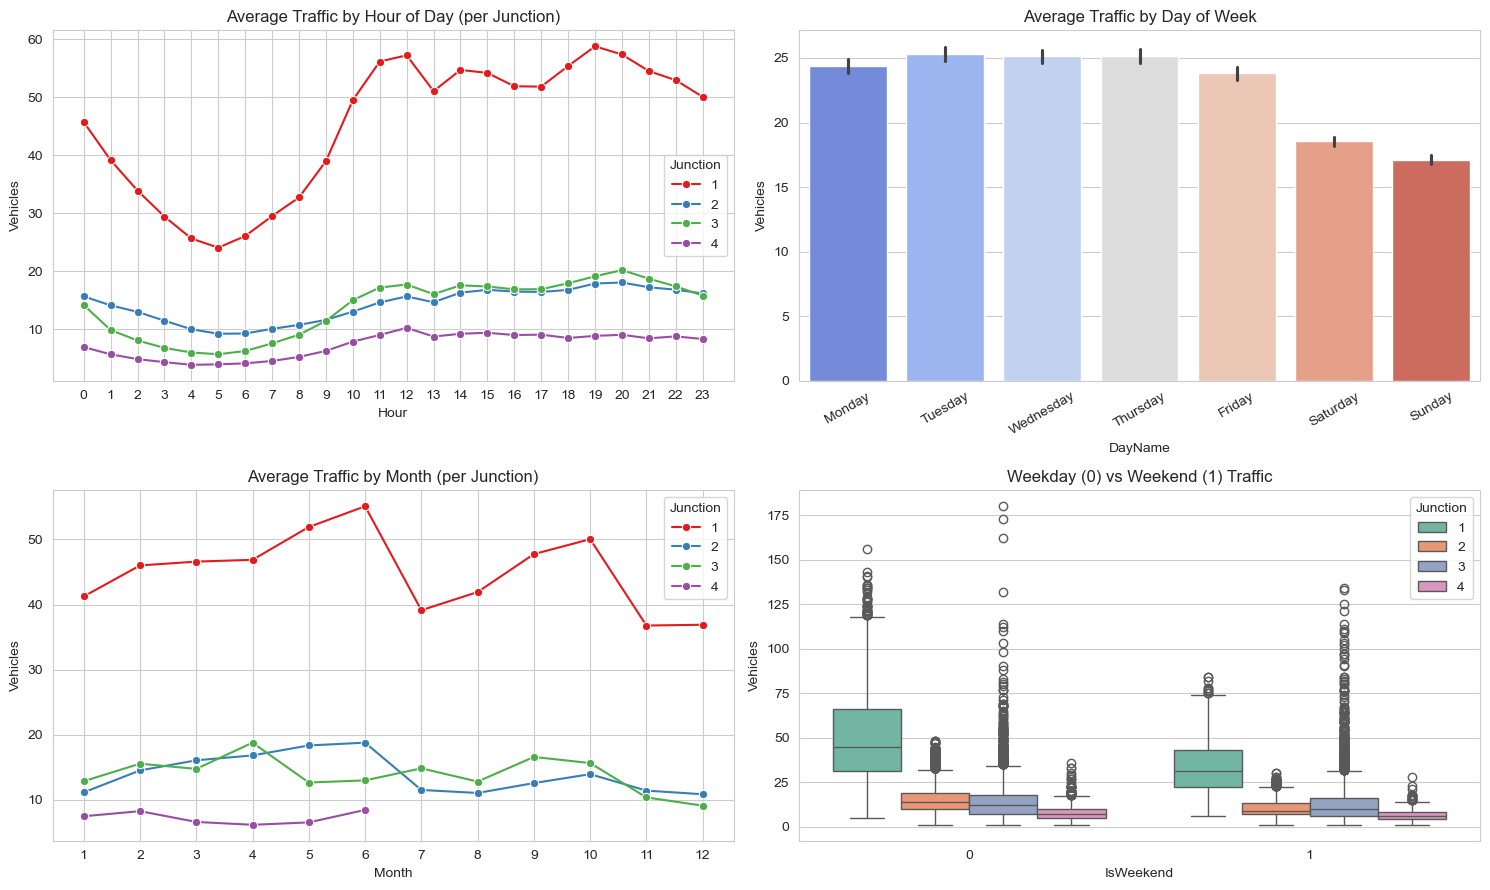

In [5]:
# --- Time-based traffic patterns ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Hourly pattern per junction
hourly = df.groupby(['Hour', 'Junction'])['Vehicles'].mean().reset_index()
sns.lineplot(data=hourly, x='Hour', y='Vehicles', hue='Junction', palette='Set1', ax=axes[0,0], marker='o')
axes[0,0].set_title('Average Traffic by Hour of Day (per Junction)')
axes[0,0].set_xticks(range(0,24))

# Weekday pattern
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.barplot(data=df, x='DayName', y='Vehicles', order=day_order, palette='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Average Traffic by Day of Week')
axes[0,1].tick_params(axis='x', rotation=30)

# Monthly pattern
monthly = df.groupby(['Month','Junction'])['Vehicles'].mean().reset_index()
sns.lineplot(data=monthly, x='Month', y='Vehicles', hue='Junction', palette='Set1', ax=axes[1,0], marker='o')
axes[1,0].set_title('Average Traffic by Month (per Junction)')
axes[1,0].set_xticks(range(1,13))

# Weekend vs weekday
sns.boxplot(data=df, x='IsWeekend', y='Vehicles', hue='Junction', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Weekday (0) vs Weekend (1) Traffic')

plt.tight_layout()
plt.show()

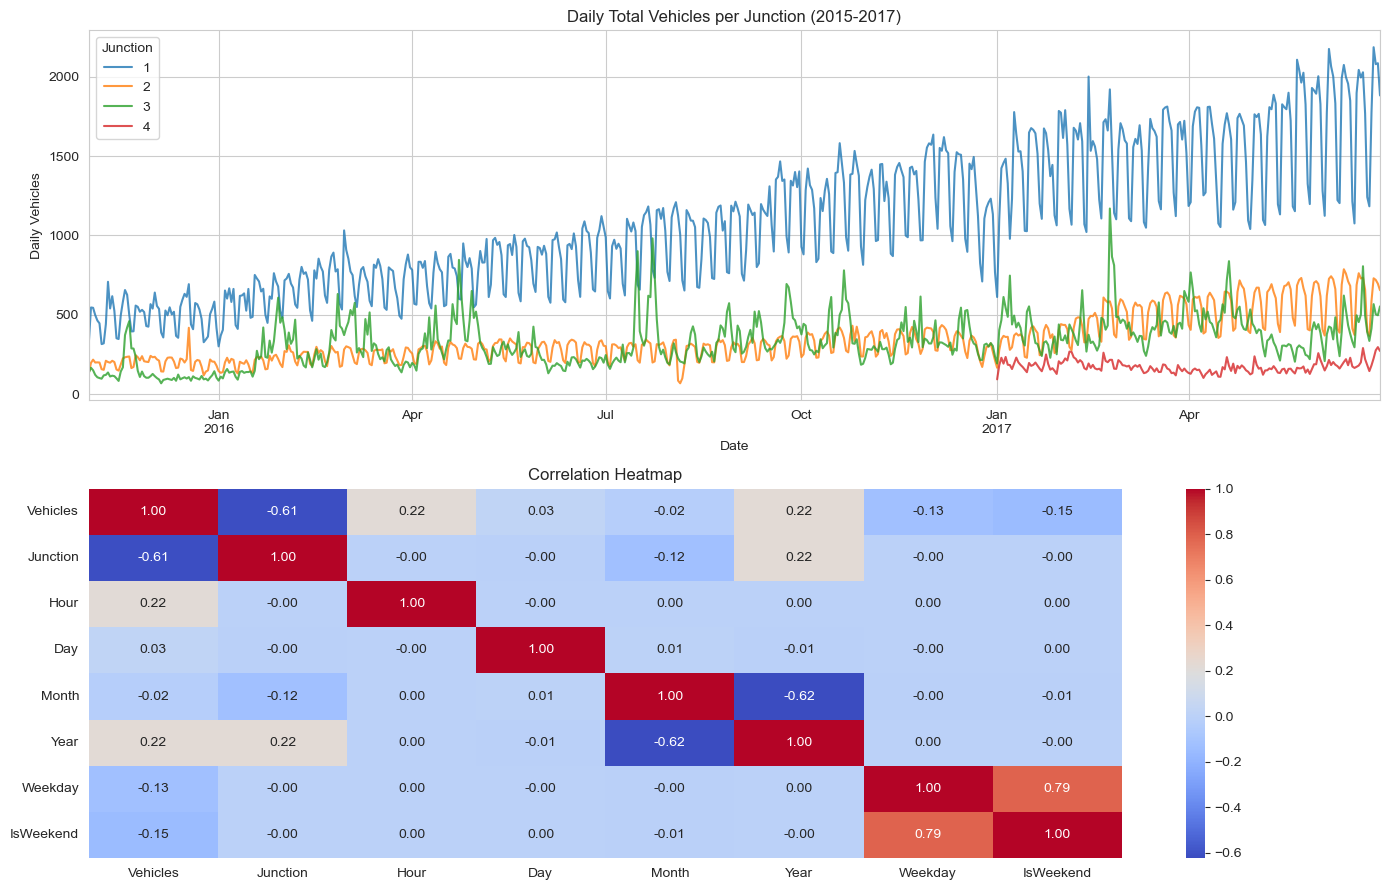

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
daily_pivot = df.assign(Date=df['DateTime'].dt.date).groupby(['Date','Junction'])['Vehicles'].sum().unstack()
daily_pivot.index = pd.to_datetime(daily_pivot.index)
daily_pivot.plot(ax=axes[0], alpha=0.8)
axes[0].set_title('Daily Total Vehicles per Junction (2015-2017)')
axes[0].set_ylabel('Daily Vehicles')
corr_cols = ['Vehicles','Junction','Hour','Day','Month','Year','Weekday','IsWeekend']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
features = ['Junction', 'Hour', 'Day', 'Month', 'Year', 'Weekday', 'IsWeekend']
X = df[features]
y = df['Vehicles']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print(f"Linear Regression | MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f} | R2: {r2_lr:.3f}")
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1).fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
print(f"Random Forest     | MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R2: {r2_rf:.3f}")

Linear Regression | MAE: 9.57 | RMSE: 12.88 | R2: 0.613
Random Forest     | MAE: 2.44 | RMSE: 3.85 | R2: 0.965


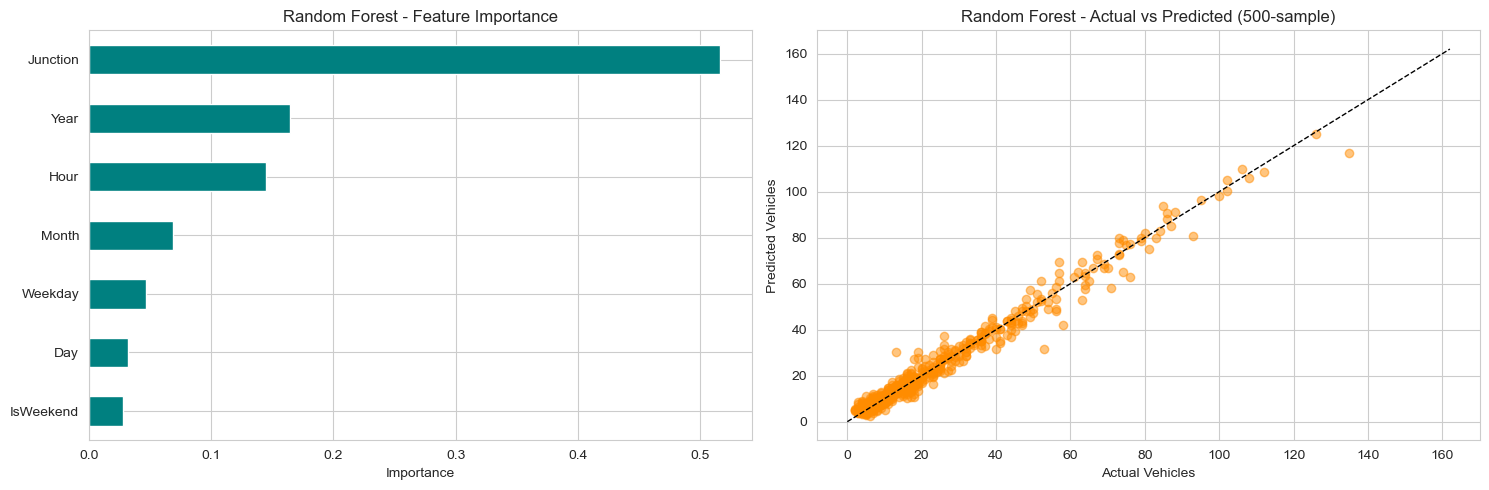

Feature importance (RF):
Junction     0.516193
Year         0.164609
Hour         0.144491
Month        0.068518
Weekday      0.046609
Day          0.032010
IsWeekend    0.027571
dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].set_xlabel('Importance')
sample = np.random.choice(len(y_test), size=500, replace=False)
axes[1].scatter(y_test.values[sample], pred_rf[sample], alpha=0.5, color='darkorange')
lims = [0, max(y_test.max(), pred_rf.max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('Actual Vehicles')
axes[1].set_ylabel('Predicted Vehicles')
axes[1].set_title('Random Forest - Actual vs Predicted (500-sample)')
plt.tight_layout()
plt.show()
print("Feature importance (RF):")
print(importances.sort_values(ascending=False))

In [24]:
junction = int(input("Junction (1-4): "))
year     = int(input("Year (e.g., 2017): "))
month    = int(input("Month (1-12): "))
day      = int(input("Day (1-31): "))
hour     = int(input("Hour (0-23): "))
prediction = predict_traffic(junction, year, month, day, hour)
print(f"\nPredicted vehicles at Junction {junction} on {year}-{month:02d}-{day:02d} {hour:02d}:00  ->  {prediction:.1f} vehicles")

Junction (1-4):  4
Year (e.g., 2017):  2018
Month (1-12):  12
Day (1-31):  31
Hour (0-23):  23



Predicted vehicles at Junction 4 on 2018-12-31 23:00  ->  12.2 vehicles
